In [2]:
from sklearn.model_selection import train_test_split

In [3]:
import sys, os 
import geopandas as gpd 
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'polygon_cleaned_with_stats.geojson')
gdf = gpd.read_file(data_path)

In [4]:
gdf 

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,poly_id,image_uid,r_mean,r_std,g_mean,g_std,b_mean,b_std,geometry
0,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,34429.374,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,0,img_0000_c4a77f3e,67.118672,63.050778,72.369456,65.615000,50.007945,48.514536,"MULTIPOLYGON (((-72.97056 10.61903, -72.97054 ..."
1,21,seasonal crops,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,6784.769,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1,img_0000_c4a77f3e,86.838321,65.381449,76.577952,58.398020,63.137208,49.598628,"MULTIPOLYGON (((-72.96914 10.61884, -72.96915 ..."
2,112,urban not continuous,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,12227.436,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,2,img_0000_c4a77f3e,57.903879,54.918250,74.354503,66.705400,39.715053,44.734299,"MULTIPOLYGON (((-72.96928 10.61948, -72.96931 ..."
3,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,19385.187,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,3,img_0000_c4a77f3e,102.817986,53.979692,107.550803,51.629908,70.705621,42.725916,"MULTIPOLYGON (((-72.97264 10.61976, -72.97273 ..."
4,313,fragmented forest,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,5013.914,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,4,img_0000_c4a77f3e,32.369521,45.569768,42.636383,57.399349,21.679273,32.445704,"MULTIPOLYGON (((-72.96917 10.62053, -72.9691 1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1948,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,1528.937,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1948,img_0029_37df798b,31.018763,45.725327,36.589655,52.510946,18.985246,29.199369,"MULTIPOLYGON (((-75.123 3.80901, -75.12297 3.8..."
1949,333,Bare areas,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,0.026,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1949,img_0029_37df798b,0.089548,2.602153,0.102208,2.904781,0.059827,1.799307,"MULTIPOLYGON (((-75.12391 3.81075, -75.1239 3...."
1950,232,wooded pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,10536.989,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1950,img_0029_37df798b,30.101152,37.576581,33.759418,39.037403,19.319645,26.745836,"MULTIPOLYGON (((-75.12278 3.8104, -75.12282 3...."
1951,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,5139.198,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1951,img_0029_37df798b,50.930026,41.676151,50.996732,40.269621,32.692476,29.041893,"MULTIPOLYGON (((-75.12367 3.81079, -75.12357 3..."


In [5]:
gdf.columns

Index(['CODIGO', 'OBSERV', 'INSUMO', 'APOYO', 'ASIGNACION', 'Asignado', 'OAM',
       'area', 'url_type', 'download_url', 'poly_id', 'image_uid', 'r_mean',
       'r_std', 'g_mean', 'g_std', 'b_mean', 'b_std', 'geometry'],
      dtype='object')

In [6]:
na_count = gdf['OBSERV'].isna().sum()
print(f"Number of NA values in 'OBSERV' column: {na_count}")


Number of NA values in 'OBSERV' column: 1


#### Cleanup : 
Lets drop the null rows which dont have labels 

In [7]:
gdf = gdf.dropna(subset=['OBSERV'])

In [8]:
print(gdf['OBSERV'].value_counts())

OBSERV
building                        683
clean pasture                   320
dense forest                    155
Bare areas                      145
urban not continuous            142
weedy pasture                   128
wooded pasture                   64
permanent crops                  57
fragmented forest                56
seasonal crops                   42
highway                          33
rivers                           21
urban                            17
Open forest                      17
lakes                            14
Secondary vegetation             14
Open grassland                   13
Shrubland                        10
Sandy areas                       6
Burnt areas                       4
comercial or industrial area      4
Dense grassland                   3
canals                            3
forest                            1
Name: count, dtype: int64


#### Cleanup : 
since we observed that those are the last categories with <10 features hence we will drop them because they are too small no of samples for model to generalize 

In [9]:
classes_to_remove = ['Sandy areas','Burnt areas','Dense grassland','comercial or industrial area', 'canals', 'forest']

gdf = gdf[~gdf['OBSERV'].isin(classes_to_remove)]

In [10]:
print(gdf['OBSERV'].value_counts())

OBSERV
building                683
clean pasture           320
dense forest            155
Bare areas              145
urban not continuous    142
weedy pasture           128
wooded pasture           64
permanent crops          57
fragmented forest        56
seasonal crops           42
highway                  33
rivers                   21
urban                    17
Open forest              17
Secondary vegetation     14
lakes                    14
Open grassland           13
Shrubland                10
Name: count, dtype: int64


### Train Split : 

We will use stratify , because we care about the distribution in class , just to make sure the class distribution is there in the test set as well 

train set distribution:
OBSERV
building                546
clean pasture           256
dense forest            124
Bare areas              116
urban not continuous    113
weedy pasture           102
wooded pasture           51
permanent crops          46
fragmented forest        45
seasonal crops           34
highway                  26
rivers                   17
urban                    14
Open forest              14
Secondary vegetation     11
lakes                    11
Open grassland           10
Shrubland                 8
Name: count, dtype: int64

 test distribution:
OBSERV
building                137
clean pasture            64
dense forest             31
urban not continuous     29
Bare areas               29
weedy pasture            26
wooded pasture           13
fragmented forest        11
permanent crops          11
seasonal crops            8
highway                   7
rivers                    4
Secondary vegetation      3
urban                     3
lakes              

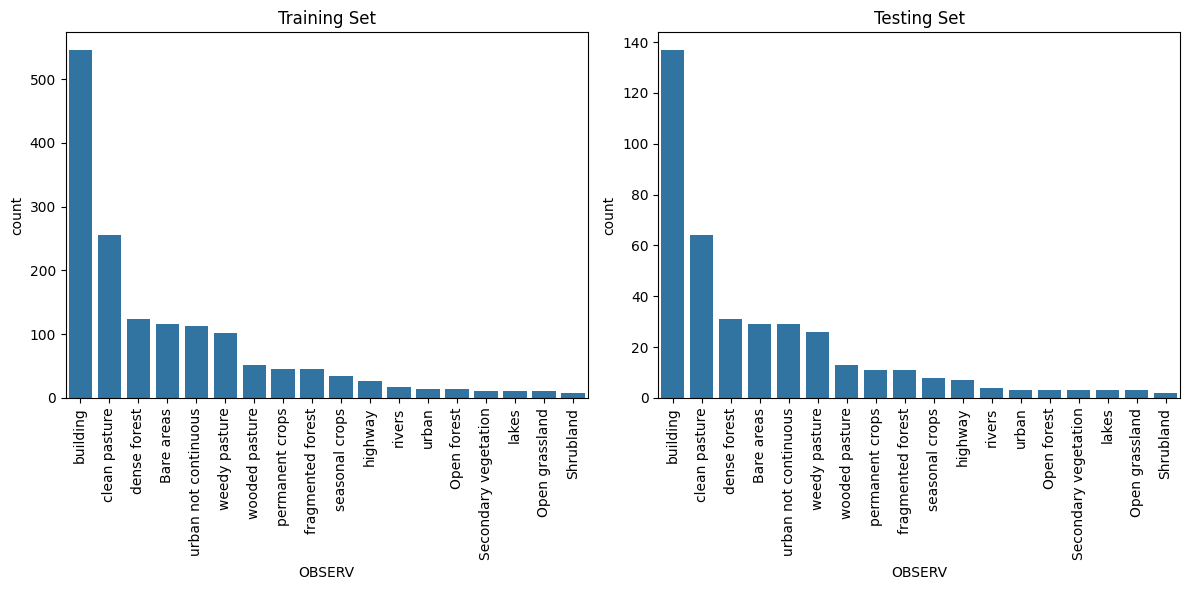

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

target = 'OBSERV'
features = ['r_mean', 'r_std', 'g_mean', 'g_std', 'b_mean', 'b_std','area']


train_gdf, test_gdf = train_test_split(gdf, test_size=0.2, random_state=42, stratify=gdf[target])

print("train set distribution:")
print(train_gdf[target].value_counts())
print("\n test distribution:")
print(test_gdf[target].value_counts())


class_order = train_gdf[target].value_counts().index

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(x=target, data=train_gdf, ax=ax[0], order=class_order)
ax[0].tick_params(axis='x', rotation=90)
ax[0].set_title("Training Set")

sns.countplot(x=target, data=test_gdf, ax=ax[1], order=class_order)
ax[1].tick_params(axis='x', rotation=90)
ax[1].set_title("Testing Set")

plt.tight_layout()
plt.show()

In [12]:
test_gdf.to_file(os.path.join(os.getcwd(),'..','data','geojson','test_files.geojson'))

In [13]:
train_gdf.to_file(os.path.join(os.getcwd(),'..','data','geojson','train_files.geojson'))